In [ ]:
import csv
import os
import pandas as pd

best_data_path = "../gedi_data/working_data/stats_results/overall_stats_best.csv"
median_data_path = "../gedi_data/working_data/stats_results/overall_stats_median.csv"

df = pd.read_csv(best_data_path)
df
df.columns = df.columns.str.strip()

scan                                   object
coarse_processing_time                float64
coarse_rank                            object
coarse_cum_error                       object
fine_processing_time                  float64
fine_rank                              object
fine_fitness                           object
fine_corr_rmse                         object
fine_nb_inliers_correspondence_set      int64
dtype: object


KeyError: '["\'\'"] not found in axis'

In [8]:
from sklearn.preprocessing import MinMaxScaler
    
def get_match_by_eig_similarity(df):   
    """
    Sort the DataFrame by 'Eig Similarity' (descending order, since Lower is better)
    and return the rank (1-based) of the first row where SCAN equals CAD.
    """
    print(df)
    df_sorted = df.sort_values('Eig Similarity', ascending=True)
    for rank, row in enumerate(df_sorted.itertuples(index=False), start=1):
        if int(row.SCAN) == int(row.CAD):
            print(rank)
            return rank
    return None
    
def get_match_rank_by_rmse(df):
    """
    Sort the DataFrame by 'RANSAC RMSE' (ascending order) and return the rank 
    (1-based) of the first row where 'SCAN' equals 'CAD'.
    
    If no such row exists, returns None.
    """
    # Sort the DataFrame by RMSE in ascending order.
    df_sorted = df.sort_values('RANSAC RMSE', ascending=True)
    
    # Iterate through the sorted rows and check if 'SCAN' equals 'CAD'
    for rank, row in enumerate(df_sorted.itertuples(index=False), start=1):
        if int(row.SCAN) == int(row.CAD):
            return rank
    return None
    
def get_match_rank_by_fitness(df):
    """
    Sort the DataFrame by 'RANSAC Fitness' (descending order, since higher is better)
    and return the rank (1-based) of the first row where SCAN equals CAD.
    """
    df_sorted = df.sort_values('RANSAC Fitness', ascending=False)
    for rank, row in enumerate(df_sorted.itertuples(index=False), start=1):
        if int(row.SCAN) == int(row.CAD):
            return rank
    return None

def get_match_rank_by_inliers(df):
    """
    Sort the DataFrame by 'Num Inliers' (descending order, since higher is better)
    and return the rank (1-based) of the first row where SCAN equals CAD.
    """
    df_sorted = df.sort_values('Num Inliers', ascending=False)
    for rank, row in enumerate(df_sorted.itertuples(index=False), start=1):
        if int(row.SCAN) == int(row.CAD):
            return rank
    return None

def get_match_by_fit_rmse(df_coarse, df_fine):
    """
    Compute a combined ranking based on fine metrics by sorting first by
    'RANSAC Fitness' (higher is better) and then by 'RANSAC RMSE' (lower is better).
    
    This function assumes that the DataFrame `df_fine` contains the columns:
        - "SCAN"
        - "CAD"
        - "RANSAC Fitness"
        - "RANSAC RMSE"
        
    It returns the 1-based rank of the first row (in the sorted order) where 
    the value in "SCAN" equals the value in "CAD". If no such row exists, it returns None.
    """
    # Sort by fitness (descending) then by RMSE (ascending)
    df_sorted = df_fine.sort_values(by=["RANSAC Fitness", "RANSAC RMSE"], ascending=[False, True])
    for rank, row in enumerate(df_sorted.itertuples(index=False), start=1):
        if int(row.SCAN) == int(row.CAD):
            return rank
    return None


In [10]:
import os
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# --- Main Processing ---
exp_folder = "../gedi_data/working_data/results/csv"
exps = os.listdir(exp_folder)

# Lists to store the DataFrames and the per-experiment results.
res_coarse = {}
res_fine = {}

for exp in exps:
    scan_num = exp.split("_")[0]
    
    # Load the fine and coarse filtering results for the current experiment
    exp_coarse_path = os.path.join(exp_folder, exp, "coarse_filtering_results.csv")
    exp_fine_path = os.path.join(exp_folder, exp, "fine_filtering_results.csv")
    
    # format columns name
    df_coarse = pd.read_csv(exp_coarse_path)
    df_coarse.columns = df_coarse.columns.str.strip()
    df_fine = pd.read_csv(exp_fine_path)
    df_fine.columns = df_fine.columns.str.strip()
    
    # Add scan column based on the file name
    df_coarse["SCAN"] = scan_num
    df_fine["SCAN"] = scan_num
    
    df_coarse = df_coarse[['SCAN', 'CAD', 'Score (lower is better)']]
    df_coarse = df_coarse.rename(columns={"Score (lower is better)": "Eig Similarity"})
    df_coarse = df_coarse.dropna()
    
    df_fine = df_fine[['SCAN', 'CAD', 'RANSAC Fitness', 'RANSAC RMSE', 'Num Inliers']]
    df_fine = df_fine.dropna()
    
    
    
    # Compute the match indices for the current experiment
    coarse_rank = get_match_by_eig_similarity(df_coarse)
    index_fitness = get_match_rank_by_fitness(df_fine)
    index_rmse = get_match_rank_by_rmse(df_fine)
    index_inliers = get_match_rank_by_inliers(df_fine)
    index_fit_rmse = get_match_by_fit_rmse(df_coarse, df_fine)
    #index_composite_coarse_and_fine = get_match_by_fit_rmse(df_coarse=df_coarse, df_fine=df_fine, eig_sim_score = 1, fitness_score = 1, rmse_score = 1)
    
    
    
    result_coarse = {
        'Experiment': exp,
        'rank_EigSimilarity': coarse_rank
    }
    
    # Store the results for this experiment in a dictionary
    result_fine = {
        'Experiment': exp,
        'rank_Fitness': index_fitness,
        'rank_RMSE': index_rmse,
        'rank_Inliers': index_inliers,
        'rank_fit_rmse': index_fit_rmse,
        #'rank_Combined_Composite': index_composite_coarse_and_fine
    }
    
    # store the results
    res_coarse[exp] = result_coarse
    res_fine[exp] = result_fine
    
# Convert the experiment results into a DataFrame for further analysis
res_coarse_df = pd.DataFrame(res_coarse).T
res_fine_df = pd.DataFrame(res_fine).T
final_result = pd.DataFrame(pd.merge(res_coarse_df, res_fine_df, on='Experiment'))
final_result.to_csv("../gedi_data/working_data/different_metric.csv", index=False)


       SCAN      CAD  Eig Similarity
0    763621   763620          0.4408
1    763621   763621          0.4458
2    763621   767340          0.5031
3    763621   794679          0.5136
4    763621   794601          0.5169
..      ...      ...             ...
309  763621   785185        424.0169
310  763621  8111409        425.9478
311  763621   793970        429.4931
312  763621   785184        443.0348
313  763621  8111520        588.8831

[314 rows x 3 columns]
2
       SCAN      CAD  Eig Similarity
0    763638   763638          0.6041
1    763638   778429          0.6788
2    763638  8091304          0.6916
3    763638   793646          0.7415
4    763638   788905          0.7468
..      ...      ...             ...
309  763638  8104629         30.8257
310  763638  8111520         34.8101
311  763638  8111409         37.9932
312  763638   785185         45.9240
313  763638   785184         47.6616

[314 rows x 3 columns]
1
       SCAN      CAD  Eig Similarity
0    763640   782016   

In [11]:
final_result

,Experiment,rank_EigSimilarity,rank_Fitness,rank_RMSE,rank_Inliers,rank_fit_rmse
0,763621_exp,2,2,1,2,1
1,763638_exp,1,1,1,1,1
2,763640_exp,4,1,1,1,1
3,763660_exp,1,1,1,1,1
4,765199_exp,2,1,1,1,1
...,...,...,...,...,...,...
304,8181356_exp,3,3,1,3,1
305,8186079_exp,3,12,18,12,12
306,8188922_exp,1,1,1,1,1
307,8188926_exp,1,1,1,1,1



Frequency Counts, Relative Percentages, and Cumulative Percentages (for ranks 1 to 5)

Metric: rank_EigSimilarity
--------------------------------------------------
Rank      Count     Percentage (%)      Cumulative (%)      
1         91        30.23               30.23               
2         47        15.61               45.85               
3         35        11.63               57.48               
4         32        10.63               68.11               
5         17        5.65                73.75               
--------------------------------------------------

Metric: rank_Fitness
--------------------------------------------------
Rank      Count     Percentage (%)      Cumulative (%)      
1         190       63.12               63.12               
2         55        18.27               81.40               
3         15        4.98                86.38               
4         12        3.99                90.37               
5         7         2.33               

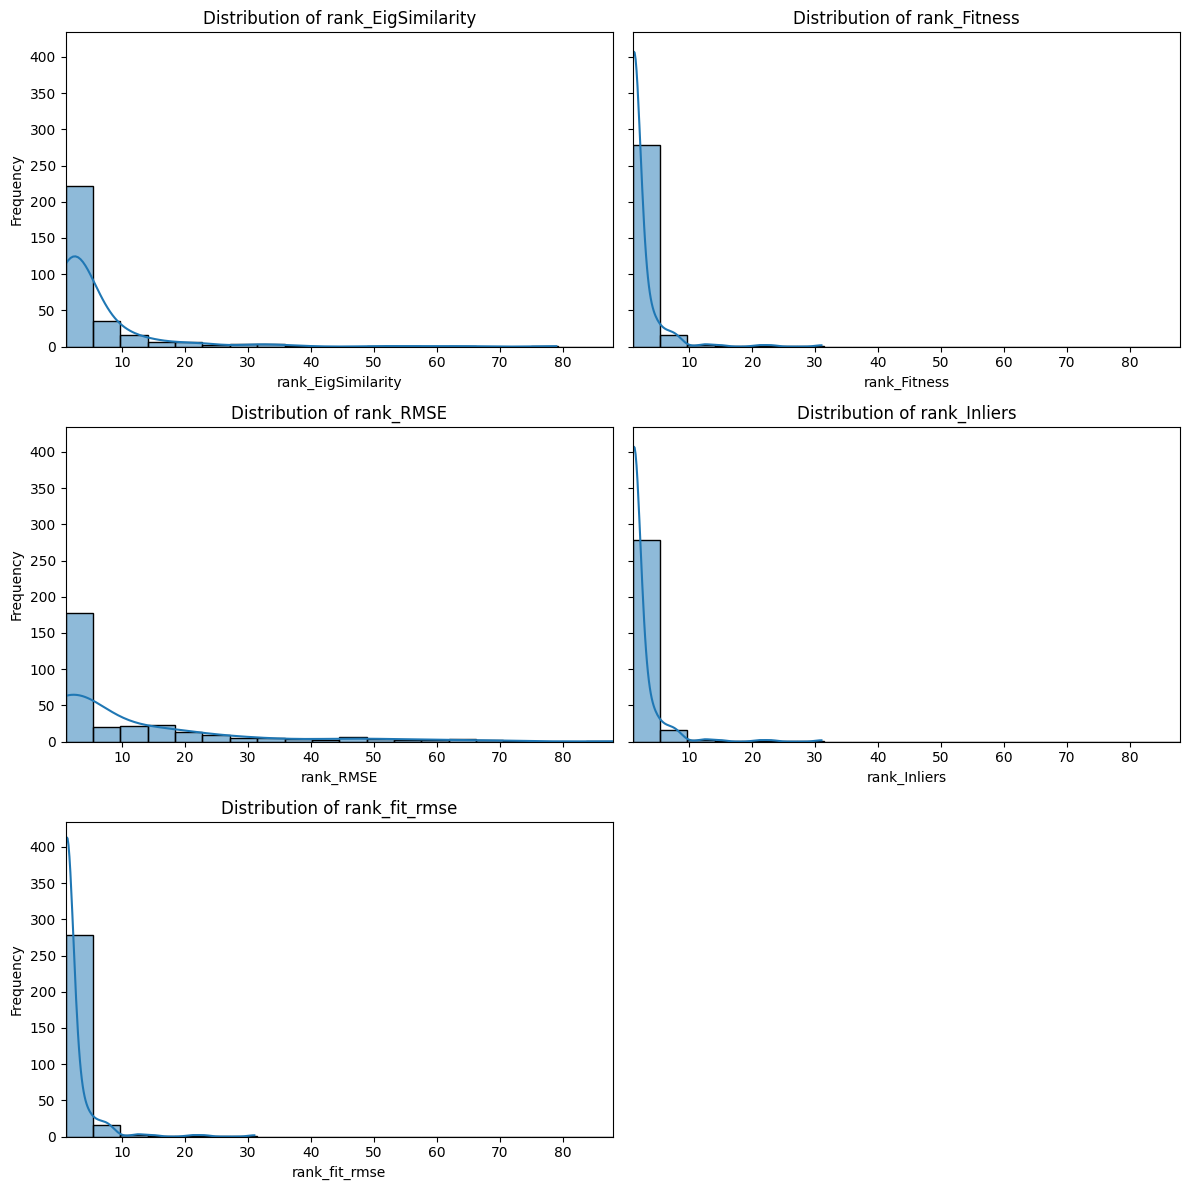


10 Worst Experiments Based on 'rank_fit_rmse':
Experiment: 785185_exp, rank_fit_rmse: 31.0
Experiment: 8166043_exp, rank_fit_rmse: 23.0
Experiment: 771742_exp, rank_fit_rmse: 21.0
Experiment: 8179609_exp, rank_fit_rmse: 15.0
Experiment: 775999_exp, rank_fit_rmse: 13.0
Experiment: 8186079_exp, rank_fit_rmse: 12.0
Experiment: 780299_exp, rank_fit_rmse: 9.0
Experiment: 784907_exp, rank_fit_rmse: 8.0
Experiment: 785159_exp, rank_fit_rmse: 8.0
Experiment: 785150_exp, rank_fit_rmse: 8.0


In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------- Data Loading & Cleaning -----------------
diff_metric_df = pd.read_csv("../gedi_data/working_data/different_metric.csv")
diff_metric_df = diff_metric_df.dropna()

# Define the metric columns
metric_columns = [
    'rank_EigSimilarity',
    'rank_Fitness', 
    'rank_RMSE', 
    'rank_Inliers', 
    'rank_fit_rmse',
]

total_experiments = len(diff_metric_df)

# ----------------- Frequency Counts, Relative %, and Cumulative % -----------------
print("\n" + "=" * 80)
print("Frequency Counts, Relative Percentages, and Cumulative Percentages (for ranks 1 to 5)")
print("=" * 80)
for col in metric_columns:
    print(f"\nMetric: {col}")
    print("-" * 50)
    print(f"{'Rank':<10}{'Count':<10}{'Percentage (%)':<20}{'Cumulative (%)':<20}")
    counts = diff_metric_df[col].value_counts().sort_index()
    cum = 0
    for rank in range(1, 6):
        count = counts.get(rank, 0)
        percentage = (count / total_experiments) * 100
        cum += count
        cum_percentage = (cum / total_experiments) * 100
        print(f"{rank:<10}{count:<10}{percentage:<20.2f}{cum_percentage:<20.2f}")
    print("-" * 50)

# ----------------- Descriptive Statistics -----------------
def print_stats(df, col):
    mean_val = df[col].mean()
    std_val = df[col].std()
    min_val = df[col].min()
    max_val = df[col].max()
    print("\n" + "=" * 50)
    print(f"{col}")
    print("=" * 50)
    print(f"{'Mean:':<10}{mean_val:.4f}")
    print(f"{'Std:':<10}{std_val:.4f}")
    print(f"{'Min:':<10}{min_val}")
    print(f"{'Max:':<10}{max_val}")

print("\n" + "=" * 80)
print("Descriptive Statistics")
print("=" * 80)
for col in metric_columns:
    print_stats(diff_metric_df, col)

# ----------------- Plotting Section -----------------
# Compute the global min and max across all metric columns to ensure a consistent x-axis scale
global_min = diff_metric_df[metric_columns].min().min()
global_max = diff_metric_df[metric_columns].max().max()

# Define bins based on global min and max (e.g., 20 bins)
bins = np.linspace(global_min, global_max, 21)

# Create a grid for 5 subplots (3 rows x 2 columns) and share the y-axis
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), sharey=True)
axs = axs.flatten()

for i, col in enumerate(metric_columns):
    ax = axs[i]
    sns.histplot(diff_metric_df[col], bins=bins, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.set_xlim(global_min, global_max)

# Hide the extra subplot (6th plot)
axs[-1].set_visible(False)

plt.tight_layout()
plt.show()

# ----------------- Identify the 10 Worst Experiments -----------------
if 'rank_fit_rmse' in diff_metric_df.columns:
    valid_df = diff_metric_df[diff_metric_df['rank_fit_rmse'].notna()]
    if not valid_df.empty:
        worst_df = valid_df.sort_values(by='rank_fit_rmse', ascending=False).head(10)
        print("\n" + "=" * 80)
        print("10 Worst Experiments Based on 'rank_fit_rmse':")
        print("=" * 80)
        for idx, row in worst_df.iterrows():
            exp_identifier = row.get('Experiment', idx)
            print(f"Experiment: {exp_identifier}, rank_fit_rmse: {row['rank_fit_rmse']}")
    else:
        print("No valid fit_rmse ranks found.")
else:
    print("'rank_fit_rmse' column not found in the data.")

In [17]:
summary_df

,Metric,Mean,Std,Min,Max,Count_1,Perc_1,CumPerc_1,Count_2,Perc_2,CumPerc_2,Count_3,Perc_3,CumPerc_3,Count_4,Perc_4,CumPerc_4,Count_5,Perc_5,CumPerc_5
0,rank_EigSimilarity,5.780731,9.220544,1.0,79.0,91,30.232558,30.232558,47,15.614618,45.847176,35,11.627907,57.475083,32,10.631229,68.106312,17,5.647841,73.754153
1,rank_Fitness,2.182724,3.040258,1.0,31.0,190,63.122924,63.122924,55,18.272425,81.395349,15,4.983389,86.378738,12,3.986711,90.365449,7,2.325581,92.691030
2,rank_RMSE,10.950166,15.836903,1.0,88.0,119,39.534884,39.534884,26,8.637874,48.172757,13,4.318937,52.491694,11,3.654485,56.146179,9,2.990033,59.136213
3,rank_Inliers,2.182724,3.040258,1.0,31.0,190,63.122924,63.122924,55,18.272425,81.395349,15,4.983389,86.378738,12,3.986711,90.365449,7,2.325581,92.691030
4,rank_fit_rmse,2.152824,3.034782,1.0,31.0,192,63.787375,63.787375,57,18.936877,82.724252,13,4.318937,87.043189,11,3.654485,90.697674,6,1.993355,92.691030
